## Deteccion de regimenes de mercado

### Veo empresas argentinas


In [145]:
import yfinance as yf

tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS', 'MELI']

data = yf.download(tickers, start='2020-01-01', end='2025-01-01')['Close']

[*********************100%***********************]  9 of 9 completed


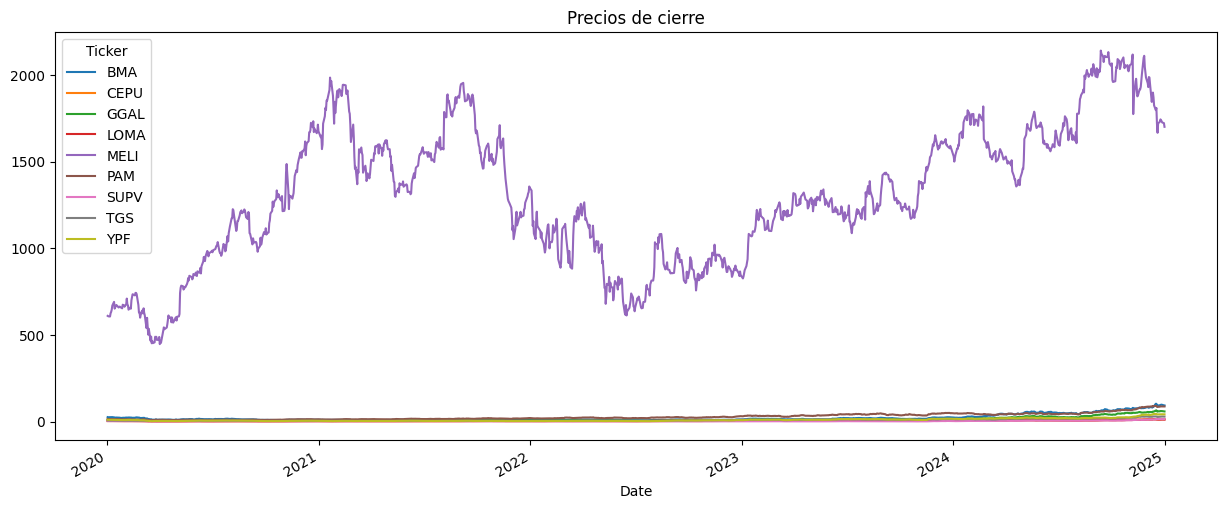

In [146]:
import matplotlib.pyplot as plt

data.plot(figsize=(15, 6), title='Precios de cierre')
plt.show()

In [ ]:
fig, axes = plt.subplots(len(data.columns), 1, figsize=(15, 4 * len(data.columns)))

for i, ticker in enumerate(data.columns):
    axes[i].plot(data.index, data[ticker])
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Precio')

plt.tight_layout()
plt.show()

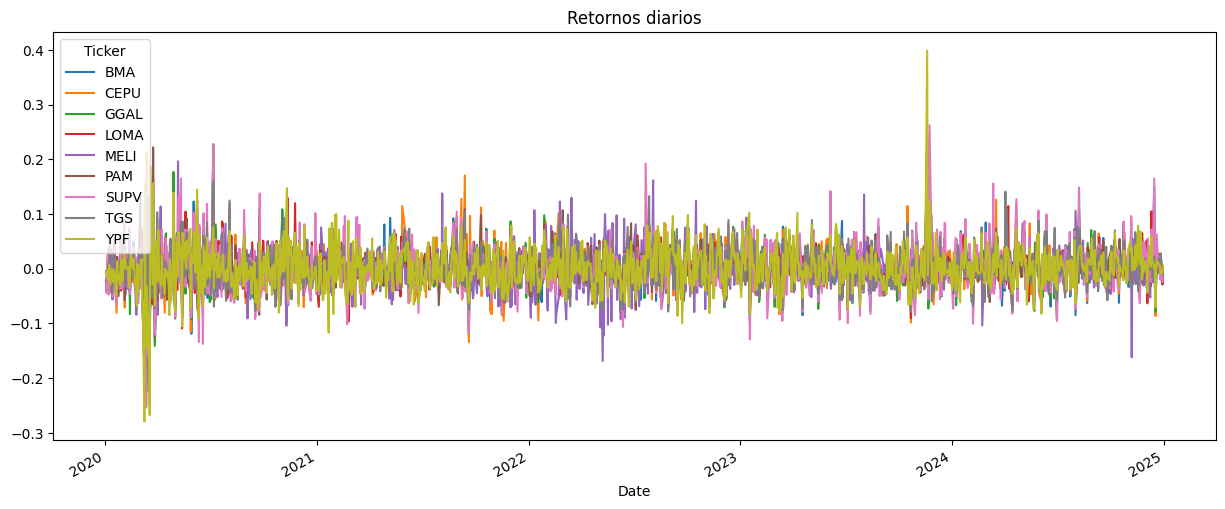

In [ ]:
returns = data.pct_change().dropna()
returns.plot(figsize=(15, 6), title='Retornos diarios')
plt.show()

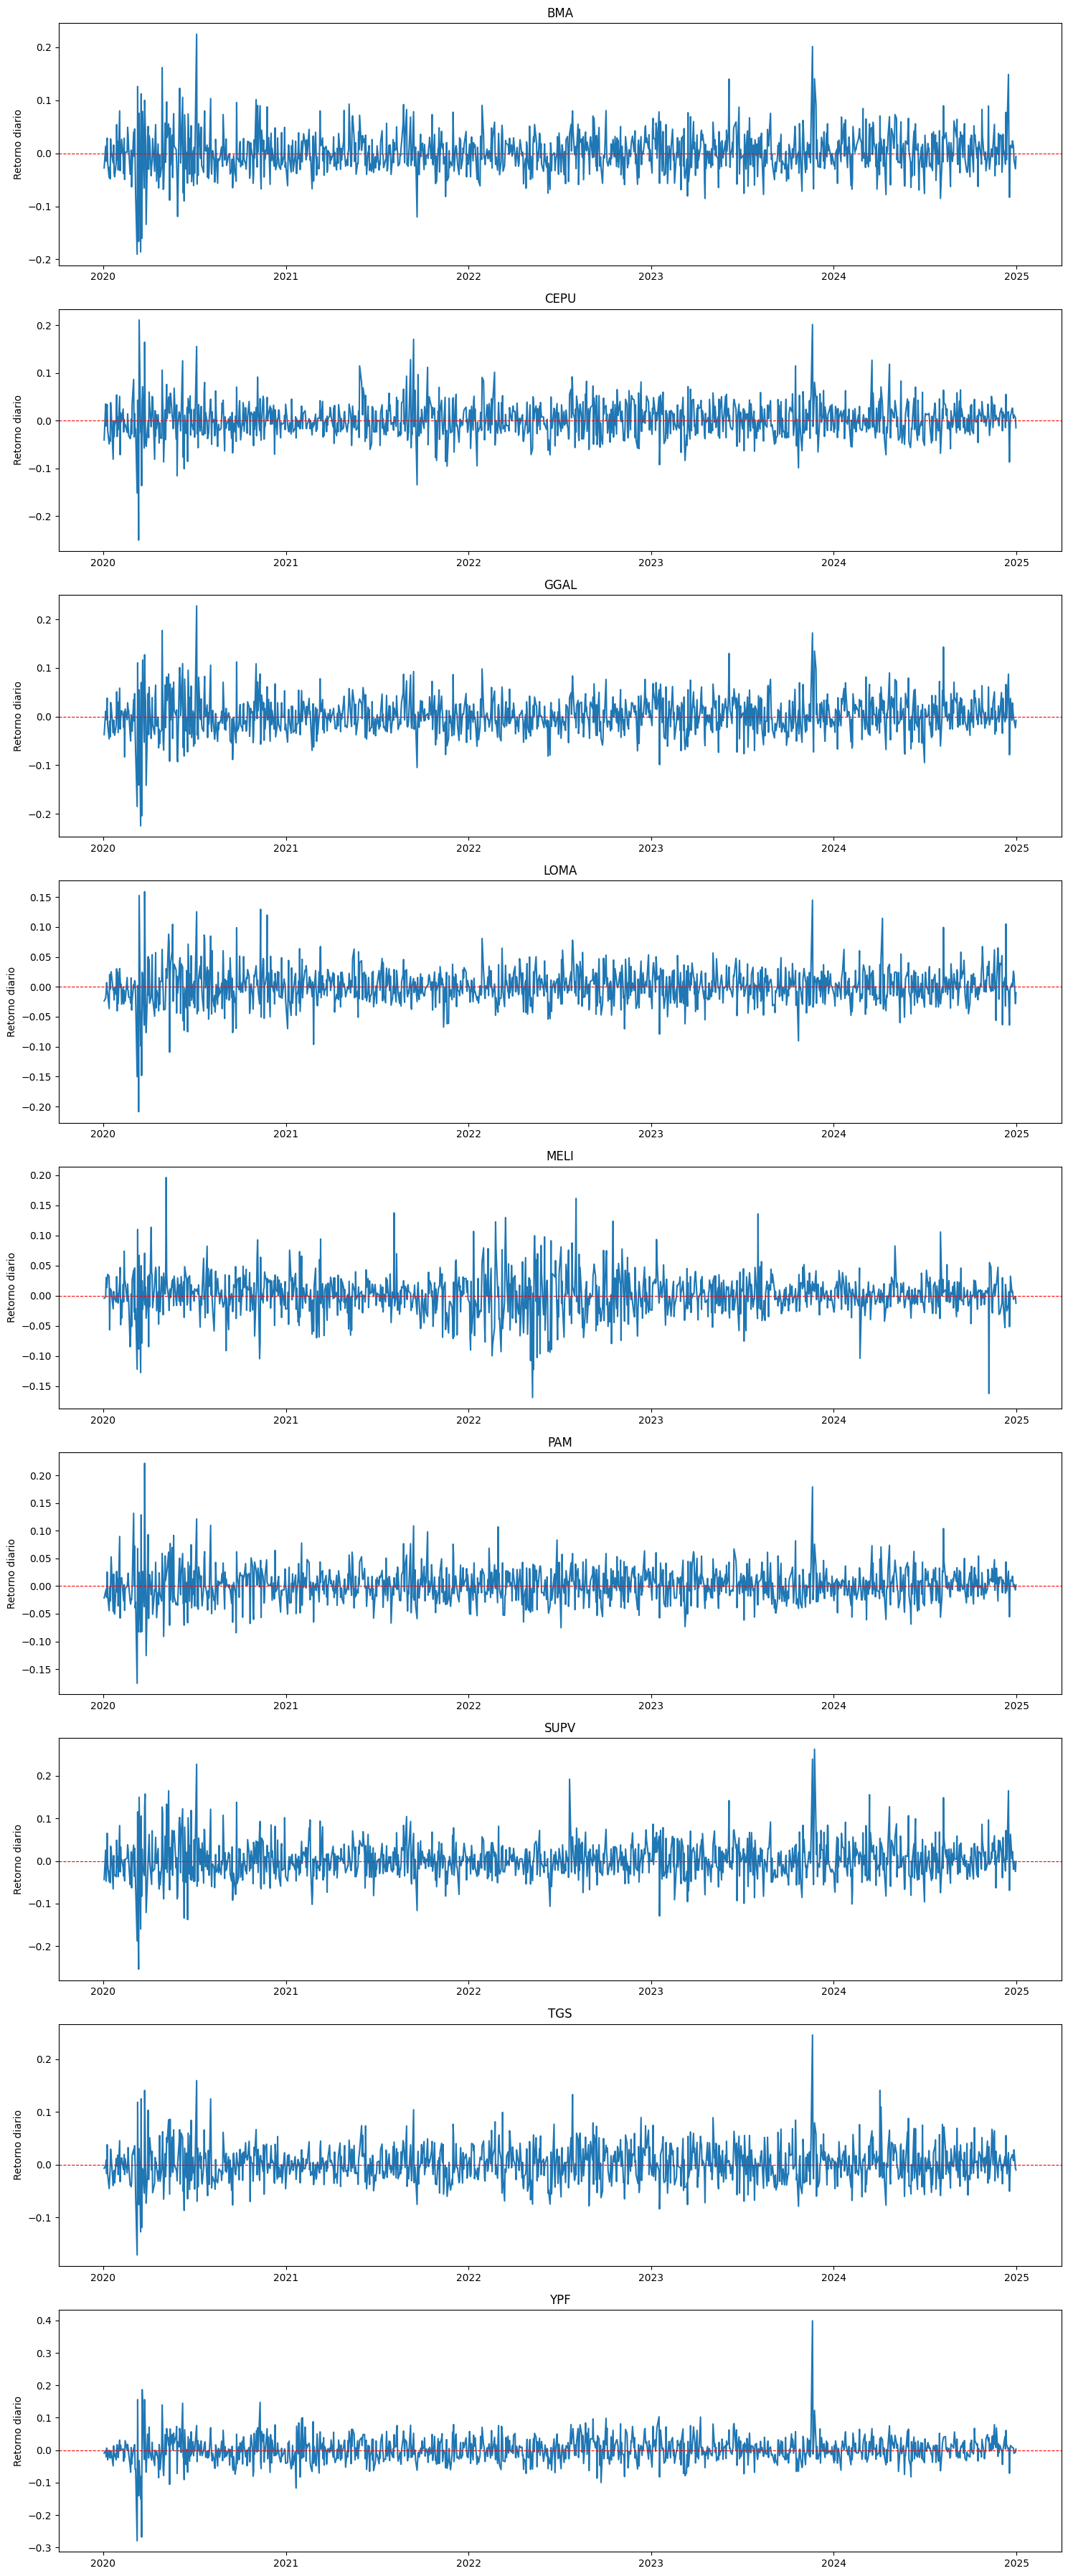

In [ ]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(15, 4 * len(returns.columns)))

for i, ticker in enumerate(returns.columns):
    axes[i].plot(returns.index, returns[ticker])
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Retorno diario')
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## Filtro de media movil


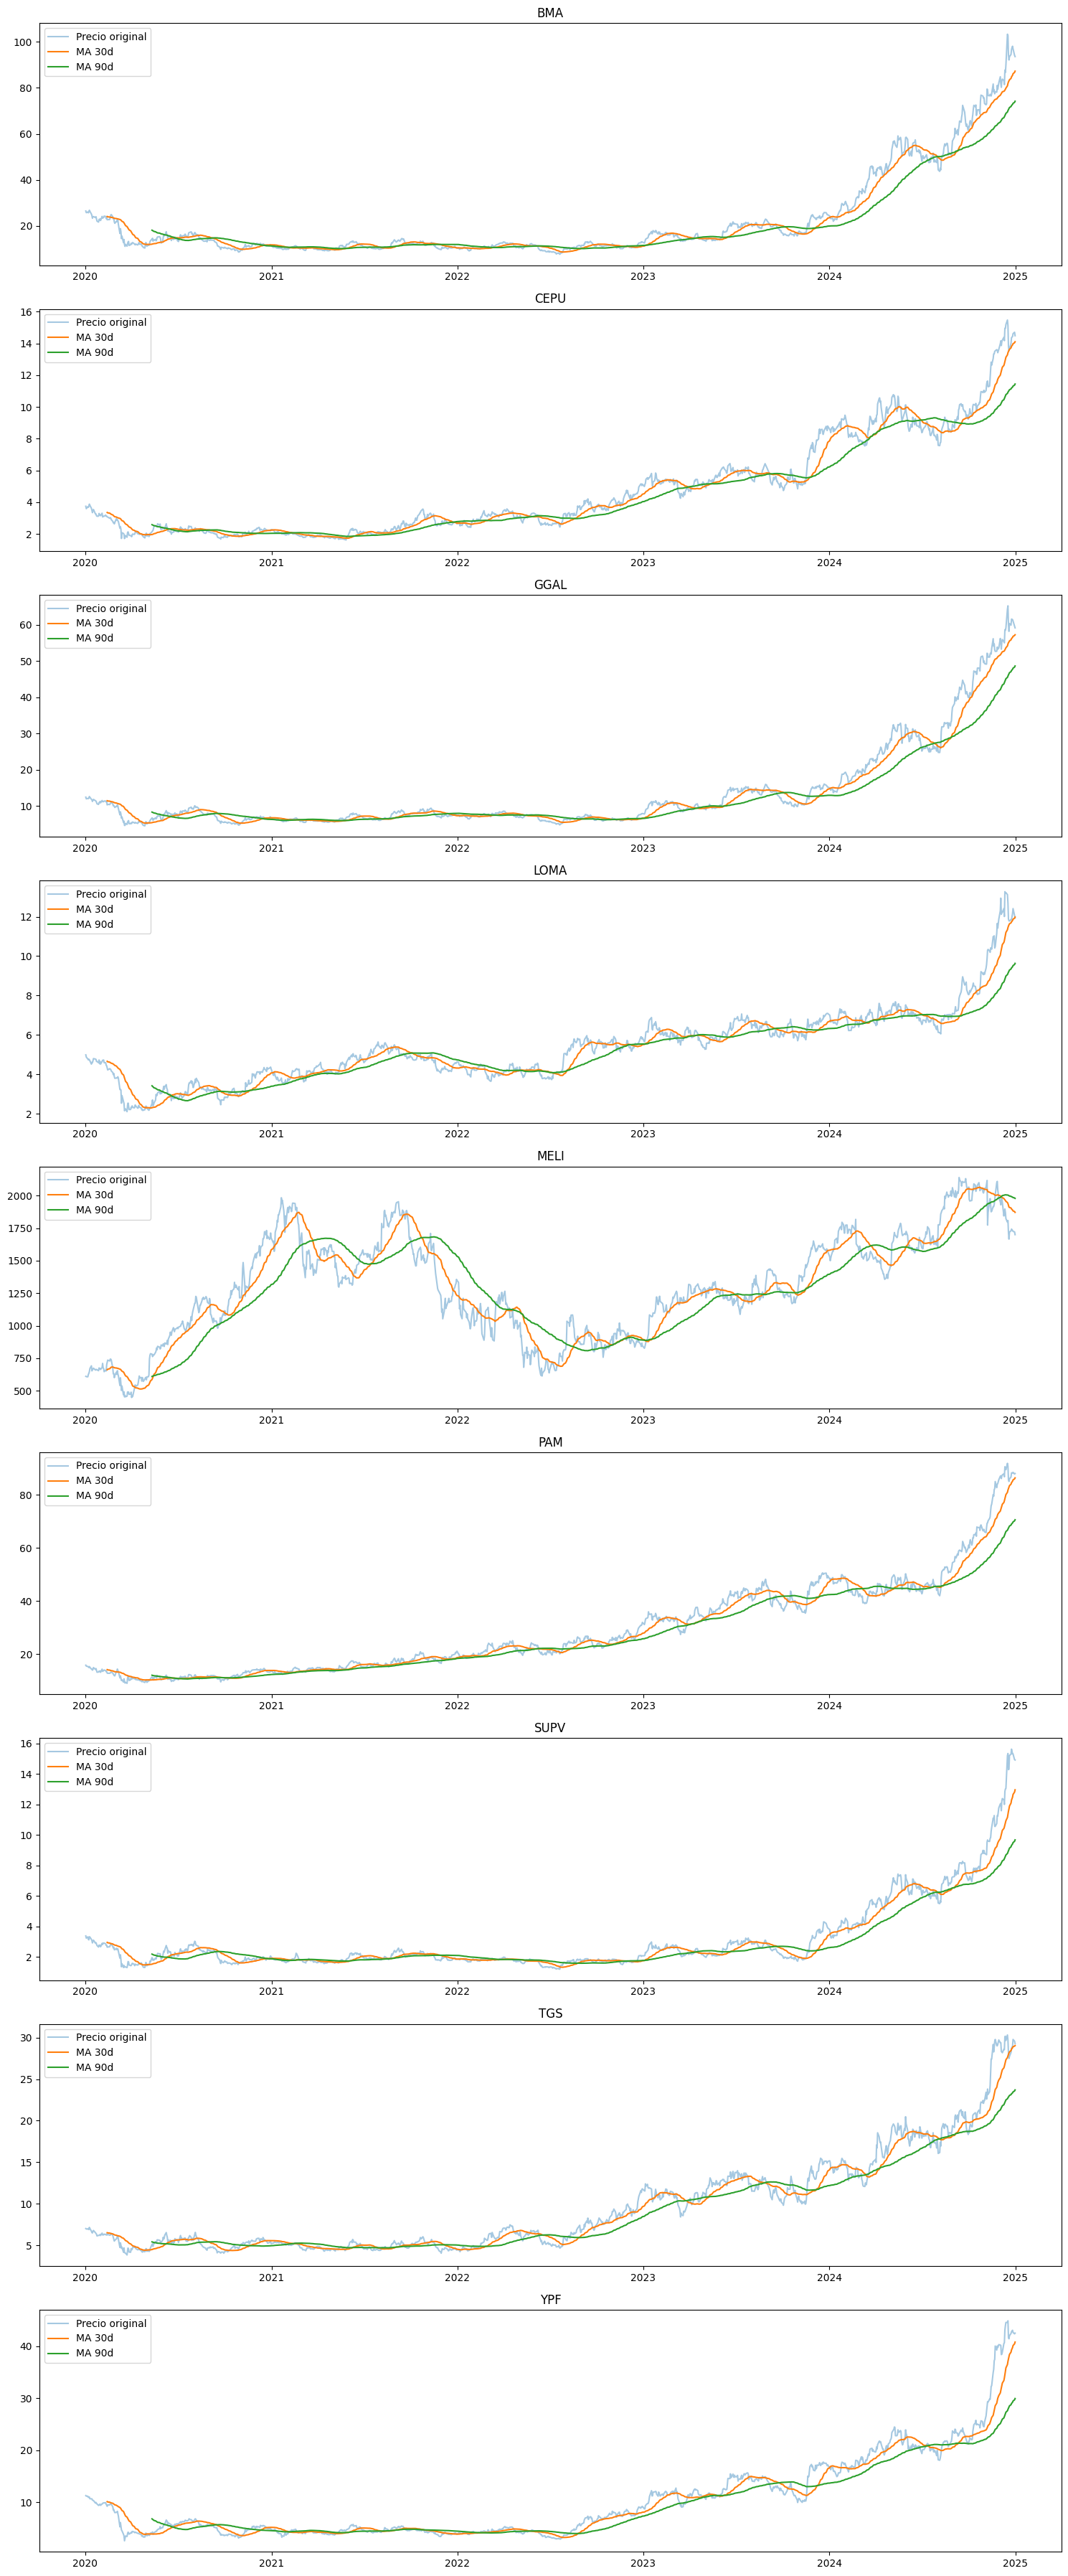

In [ ]:
fig, axes = plt.subplots(len(data.columns), 1, figsize=(15, 4 * len(data.columns)))

ventanas = [30, 90]  # 1 mes y 3 meses

for i, ticker in enumerate(data.columns):
    axes[i].plot(data.index, data[ticker], alpha=0.4, label='Precio original')
    
    for ventana in ventanas:
        ma = data[ticker].rolling(window=ventana).mean()
        axes[i].plot(data.index, ma, label=f'MA {ventana}d')
    
    axes[i].set_title(ticker)
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Cuando la media movil corta (30 dias) corta a las larga (90 dias) hacia arriba -> la tendencia reciente es mas fuerte que la tendencia de fondo (alcista)
#### Cuando corta habia abajo -> la reciente es mas debir que la de fondo (bajista)


##### Veo que las empresas argentinas muestran señales de estar en tendencia alcista, miestras que meli entro en bajista hace unos mesas

## Veamos la FFT y filtremos las frecuencias altas para reducir el ruido

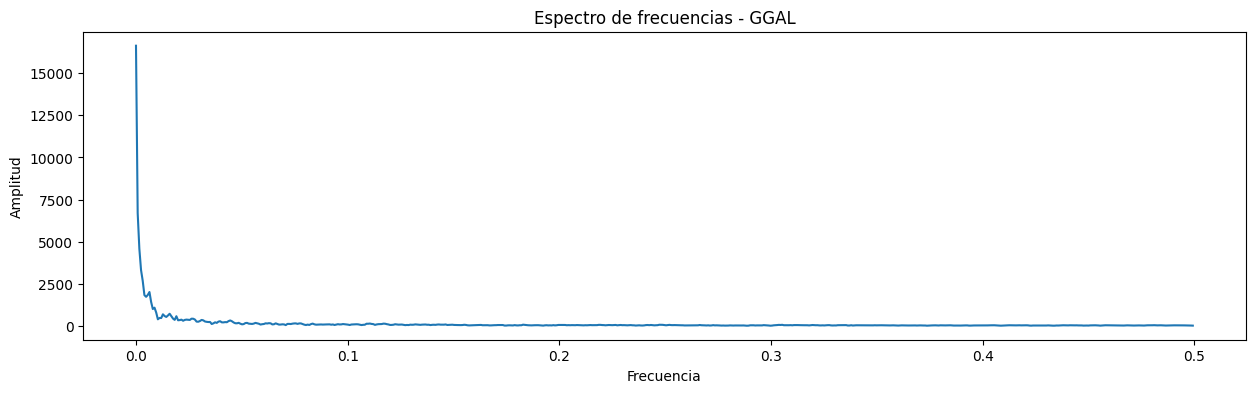

In [ ]:
import numpy as np

ticker = 'GGAL'
precios = data[ticker].dropna().values

# Aplicamos FFT
fft = np.fft.fft(precios)
frecuencias = np.fft.fftfreq(len(precios))

# Graficamos el espectro de frecuencias
plt.figure(figsize=(15, 4))
plt.plot(frecuencias[:len(frecuencias)//2], 
         np.abs(fft[:len(fft)//2]))
plt.title(f'Espectro de frecuencias - {ticker}')
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.show()

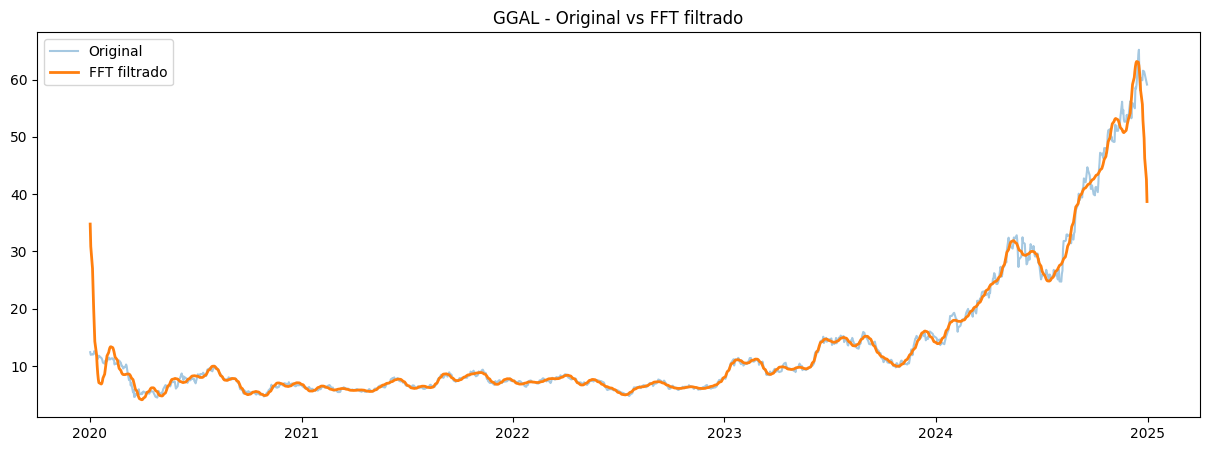

In [ ]:
# Copiamos el resultado de la FFT
fft_filtrado = fft.copy()

# Umbral - eliminamos frecuencias altas
umbral = 0.04
fft_filtrado[np.abs(frecuencias) > umbral] = 0

# Reconstruimos la señal con IFFT
precio_filtrado = np.fft.ifft(fft_filtrado).real

# Comparamos original vs filtrado
plt.figure(figsize=(15, 5))
plt.plot(data.index[data[ticker].notna()], precios, alpha=0.4, label='Original')
plt.plot(data.index[data[ticker].notna()], precio_filtrado, label='FFT filtrado', linewidth=2)
plt.title(f'{ticker} - Original vs FFT filtrado')
plt.legend()
plt.show()

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np

def butterworth_filter(data, cutoff, fs=1, order=4):
    nyq = fs / 2
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

# Filtrado rolling - solo usa historia disponible hasta cada punto
fechas = data.index[data[ticker].notna()]
precios = data[ticker].dropna().values
precio_filtrado_rolling = []

for i in range(len(precios)):
    if i < 30:
        precio_filtrado_rolling.append(np.nan)
    else:
        segmento = precios[:i+1]
        filtrado = butterworth_filter(segmento, cutoff=0.05)
        precio_filtrado_rolling.append(filtrado[-1])

precio_filtrado = np.array(precio_filtrado_rolling)

# Eliminamos los primeros 30 dias
mask = ~np.isnan(precio_filtrado)
precio_filtrado = precio_filtrado[mask]
precios = precios[mask]
fechas = fechas[mask]

### con la señal filtrada puedo ver las tendencias en base a  la derivada


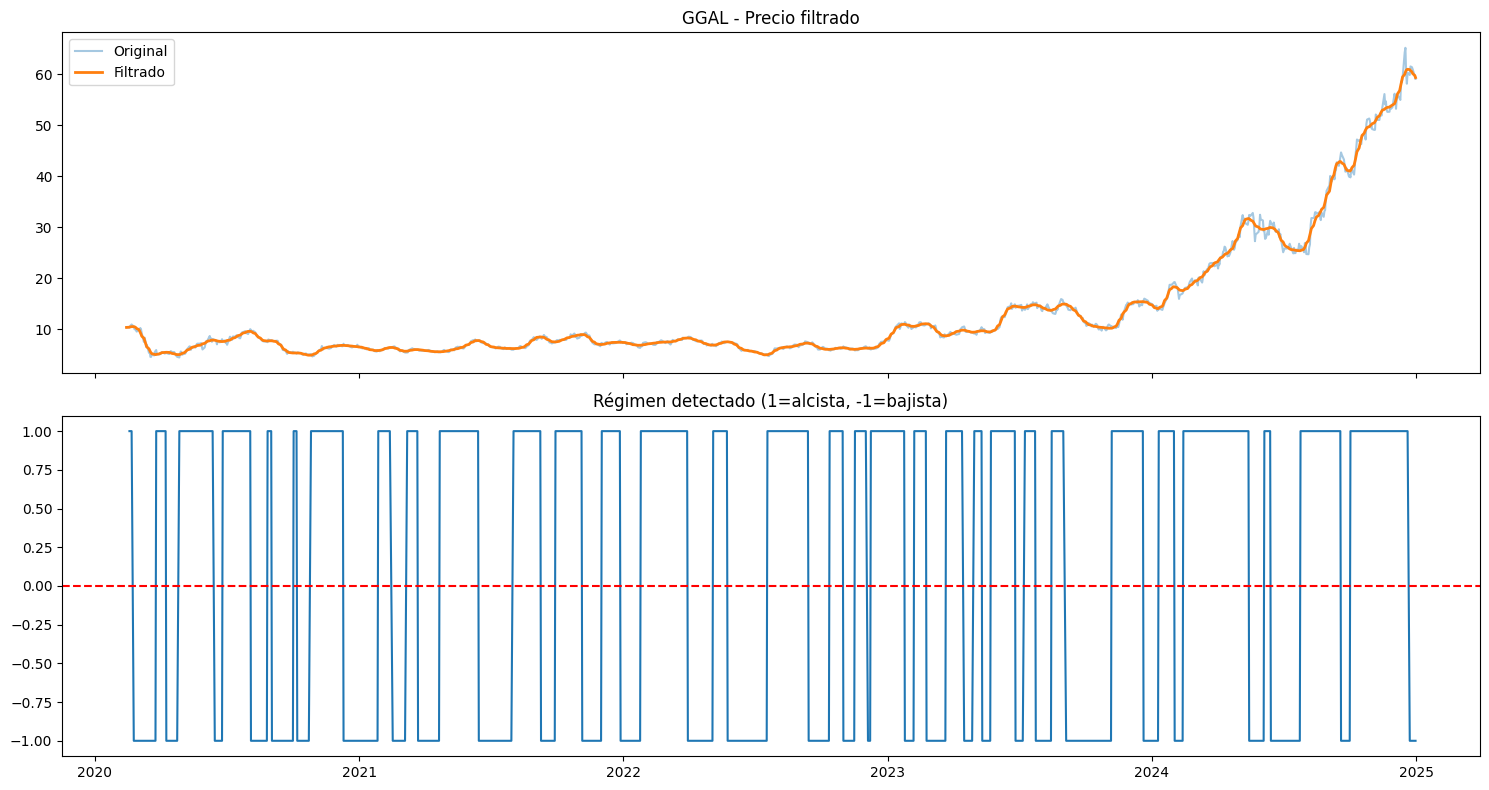

In [ ]:
precio_filtrado = butterworth_filter(precios, cutoff=0.05)

# Derivada - cuanto cambia la señal filtrada de un dia al otro
derivada = np.diff(precio_filtrado)

# Regimen: 1 = alcista, -1 = bajista
regimen = np.where(derivada > 0, 1, -1)

# Graficamos precio con regimen coloreado
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

#fechas = data.index[data[ticker].notna()]

ax1.plot(fechas, precios, alpha=0.4, label='Original')
ax1.plot(fechas, precio_filtrado, label='Filtrado', linewidth=2)
ax1.set_title(f'{ticker} - Precio filtrado')
ax1.legend()

ax2.plot(fechas[1:], regimen)
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_title('Régimen detectado (1=alcista, -1=bajista)')

plt.tight_layout()
plt.show()

In [ ]:
# Identificamos los cambios de regimen
cambios = np.where(np.diff(regimen) != 0)[0] + 1

# Agregamos inicio y fin
breakpoints = np.concatenate([[0], cambios, [len(regimen)]])

# Calculamos duracion y tipo de cada regimen
regimenes = []
for i in range(len(breakpoints) - 1):
    inicio = breakpoints[i]
    fin = breakpoints[i + 1]
    duracion = fin - inicio
    tipo = regimen[inicio]
    regimenes.append({
        'inicio': fechas[inicio],
        'fin': fechas[fin],
        'duracion': duracion,
        'tipo': 'alcista' if tipo == 1 else 'bajista'
    })

import pandas as pd
df_regimenes = pd.DataFrame(regimenes)
print(df_regimenes)

       inicio        fin  duracion     tipo
0  2020-02-14 2020-02-21         4  alcista
1  2020-02-21 2020-03-25        23  bajista
2  2020-03-25 2020-04-08        10  alcista
3  2020-04-08 2020-04-24        11  bajista
4  2020-04-24 2020-06-12        34  alcista
..        ...        ...       ...      ...
57 2024-06-13 2024-07-24        27  bajista
58 2024-07-24 2024-09-18        39  alcista
59 2024-09-18 2024-10-01         9  bajista
60 2024-10-01 2024-12-20        57  alcista
61 2024-12-20 2024-12-31         6  bajista

[62 rows x 4 columns]


In [ ]:
for tipo in ['alcista', 'bajista']:
    subset = df_regimenes[df_regimenes['tipo'] == tipo]['duracion']
    print(f"{tipo}:")
    print(f"  Promedio: {subset.mean():.1f} días")
    print(f"  Varianza: {subset.var():.1f}")
    print(f"  Mínimo:   {subset.min()} días")
    print(f"  Máximo:   {subset.max()} días")
    print(f"  Cantidad: {len(subset)} regímenes")
    print()

alcista:
  Promedio: 22.4 días
  Varianza: 239.9
  Mínimo:   3 días
  Máximo:   63 días
  Cantidad: 31 regímenes

bajista:
  Promedio: 17.2 días
  Varianza: 91.1
  Mínimo:   4 días
  Máximo:   45 días
  Cantidad: 31 regímenes



### hay mucha varianza en los regimenes alcistas como para predecir bien solo con esto cuanto tiempo va a durar

### Buscamos 

###  Features técnicas — vienen de la propia señal de precios
###  Features macro — contexto externo

Reversión a la media es la idea de que los precios (o en este caso las duraciones) tienden a volver a su promedio histórico con el tiempo.

## Construimos el dataframe completo

In [ ]:
# Partimos del regimen que ya calculaste
df_features = pd.DataFrame(index=fechas[1:])
df_features['precio'] = precios[1:]
df_features['precio_filtrado'] = precio_filtrado[1:]
df_features['regimen'] = regimen

# Dias transcurridos en el regimen actual
dias_en_regimen = []
contador = 0
for i in range(len(regimen)):
    if i == 0 or regimen[i] == regimen[i-1]:
        contador += 1
    else:
        contador = 1
    dias_en_regimen.append(contador)

df_features['dias_en_regimen'] = dias_en_regimen

# Pendiente de la señal filtrada
df_features['pendiente'] = np.diff(precio_filtrado, prepend=precio_filtrado[0])[1:]

ventana = 7
target = []

for i in range(len(df_features)):
    if i + ventana >= len(df_features):
        target.append(np.nan)  # ultimos dias no tienen ventana completa
    elif df_features['regimen'].iloc[i] != df_features['regimen'].iloc[i + ventana]:
        target.append(1)
    else:
        target.append(0)

df_features['target'] = target
df_features = df_features.dropna(subset=['target'])
df_features['target'] = df_features['target'].astype(int)

print(df_features['target'].value_counts(normalize=True))

target
0    0.669672
1    0.330328
Name: proportion, dtype: float64


In [ ]:
# Fechas de elecciones nacionales argentinas
elecciones = pd.to_datetime([
    '2021-09-12',  # PASO 2021 legislativas
    '2021-11-14',  # Generales 2021 legislativas
    '2023-08-13',  # PASO 2023 presidenciales
    '2023-10-22',  # Generales 2023 presidenciales
    '2023-11-19',  # Ballotage 2023
    '2025-10-26',  # Generales 2025 legislativas (sin PASO)
])

tipo_eleccion = {
    '2021-09-12': 'legislativa',
    '2021-11-14': 'legislativa',
    '2023-08-13': 'presidencial',
    '2023-10-22': 'presidencial',
    '2023-11-19': 'presidencial',
    '2025-10-26': 'legislativa',
}
peso_eleccion = {
    'presidencial': 2,
    'legislativa': 0.5,
}
# Dias hasta la proxima eleccion para cada fecha
def dias_hasta_eleccion_ponderado(fecha):
    futuras = elecciones[elecciones > fecha]
    if len(futuras) == 0:
        return 999
    proxima = futuras.min()
    tipo = tipo_eleccion[str(proxima.date())]
    dias = (proxima - fecha).days
    return dias / peso_eleccion[tipo]

df_features['dias_hasta_eleccion'] = [
    dias_hasta_eleccion_ponderado(f) for f in df_features.index
]

In [ ]:
# Bajamos ARGT
argt = yf.download('ARGT', start='2020-01-01', end='2025-01-01')['Close']

# Variable binaria
argt_binario = (argt.pct_change() > 0).astype(int)
argt_binario = argt_binario.squeeze()
argt_binario.name = 'riesgo_pais_sube'

# Removemos timezone si existe
argt_binario.index = argt_binario.index.tz_localize(None)

# Mergeamos
df_features = df_features.join(argt_binario, how='left')
df_features['riesgo_pais_sube'] = df_features['riesgo_pais_sube'].ffill()
df_features = df_features.drop(columns=[ 'precio', 'precio_filtrado'])
print(df_features.head())
print(df_features.isnull().sum())


[*********************100%***********************]  1 of 1 completed

            regimen  dias_en_regimen  pendiente  target  dias_hasta_eleccion  \
Date                                                                           
2020-02-18        1                1   0.047096       1                572.0   
2020-02-19        1                2   0.046213       1                571.0   
2020-02-20        1                3   0.037720       1                570.0   
2020-02-21        1                4   0.021698       1                569.0   
2020-02-24       -1                1  -0.001571       0                566.0   

            riesgo_pais_sube  
Date                          
2020-02-18                 0  
2020-02-19                 1  
2020-02-20                 1  
2020-02-21                 1  
2020-02-24                 0  
regimen                0
dias_en_regimen        0
pendiente              0
target                 0
dias_hasta_eleccion    0
riesgo_pais_sube       0
dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_features.drop(columns=['target'])
y = df_features['target']

# Split temporal - no aleatorio
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       176
           1       0.63      0.38      0.48        68

    accuracy                           0.77       244
   macro avg       0.71      0.65      0.66       244
weighted avg       0.75      0.77      0.75       244



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

scorer = make_scorer(recall_score)

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor recall en CV:", grid_search.best_score_)

# Evaluamos en test
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(classification_report(y_test, predictions))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Mejor recall en CV: 0.5910447761194031
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       176
           1       0.45      0.44      0.45        68

    accuracy                           0.70       244
   macro avg       0.62      0.62      0.62       244
weighted avg       0.69      0.70      0.70       244



### Tengo muy pocos en el target 1 (5%)